<a href="https://colab.research.google.com/github/DhairyaDave08/Machine-Learning/blob/main/Basic_Maths/ImageCompression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Compression Using Low Rank Approximation**


In [1]:
import numpy as np  #For Array
import pandas as pd  #For data files /cv /dataframes
import matplotlib.pyplot as plt  #for plotting
import cv2 as cv  #for images operation
from google.colab.patches import cv2_imshow #Used only in Google Colab. Normal cv.imshow() does not work properly in Colab.
from skimage import io  #reading/saving images
from PIL import Image  #image operations

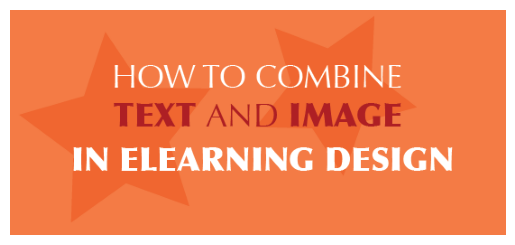



 [[121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]
 ...
 [121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]]


 (250, 550) 




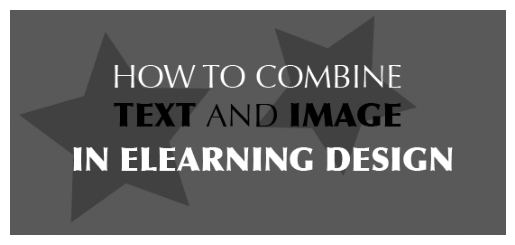


 (250, 550)


In [2]:
url = "https://theelearningcoach.com/wp-content/uploads/2017/01/text-image-title.png"
mimg = io.imread(url)
plt.imshow(mimg)
plt.axis('off')
plt.show()
gray_image = cv.cvtColor(mimg, cv.COLOR_BGR2GRAY)
i_mat = np.array(list(gray_image), float)
print("\n\n",i_mat)
print("\n\n",i_mat.shape,"\n\n")
plt.imshow(i_mat, cmap='gray')
plt.axis('off')
plt.show()
print("\n",i_mat.shape)

In [3]:
U,S,VT = np.linalg.svd(i_mat, full_matrices=True)
print(U.shape,S.shape,VT.shape)

(250, 250) (250,) (550, 550)


In [4]:
SD = np.zeros((250,550))
SD[:250,:250] = np.diag(S)
print(SD)

[[46042.21625916     0.             0.         ...     0.
      0.             0.        ]
 [    0.          5754.27929883     0.         ...     0.
      0.             0.        ]
 [    0.             0.          3774.05283506 ...     0.
      0.             0.        ]
 ...
 [    0.             0.             0.         ...     0.
      0.             0.        ]
 [    0.             0.             0.         ...     0.
      0.             0.        ]
 [    0.             0.             0.         ...     0.
      0.             0.        ]]


[[121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]
 ...
 [121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]
 [121. 121. 121. ... 121. 121. 121.]]


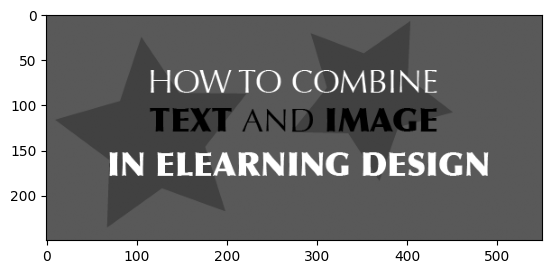

In [5]:
print(U.dot(SD).dot(VT))
plt.imshow(U.dot(SD).dot(VT), cmap='gray')

In [6]:
from ipywidgets import interact, IntSlider

def compress(r):
    s = S[:r]
    sd = np.diag(s)
    u = U[:, :r]
    vt = VT[:r, :]

    img_compressed = u @ sd @ vt

    plt.figure(figsize=(6,6))
    plt.imshow(img_compressed, cmap='gray')
    plt.title(f"Rank = {r}")
    plt.axis('off')
    plt.show()

interact(
    compress,
    r=IntSlider(
        min=1,
        max=250,
        step=1,
        value=25
    )
)

interactive(children=(IntSlider(value=25, description='r', max=250, min=1), Output()), _dom_classes=('widget-i…

<function __main__.compress(r)>

#**Colourful Image Compression**(tensor to Matrix)

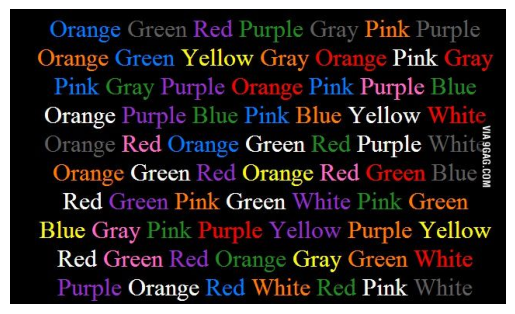

(380, 639, 3)


In [7]:
url = "https://i.pinimg.com/736x/1d/85/24/1d85244781fb68a4a23ccc6c8f3ea847.jpg"
myImg = io.imread(url)
plt.imshow(myImg)
plt.axis('off')
plt.show()
print(np.shape(myImg))

In [8]:
img1=myImg[:,:,0]
img2=myImg[:,:,1]
img3=myImg[:,:,2]
print(img1.shape,img2.shape,img3.shape)

(380, 639) (380, 639) (380, 639)


In [9]:
u1,s1,vt1=np.linalg.svd(img1,full_matrices=True)
u2,s2,vt2=np.linalg.svd(img2,full_matrices=True)
u3,s3,vt3=np.linalg.svd(img3,full_matrices=True)
print(s1.shape,s2.shape,s3.shape)

(380,) (380,) (380,)


In [10]:
sd1=np.zeros((380,380))
sd2=np.zeros((380,380))
sd3=np.zeros((380,380))
sd1=np.diag(s1)
sd2=np.diag(s2)
sd3=np.diag(s3)
print(sd1.shape,sd2.shape,sd3.shape)

(380, 380) (380, 380) (380, 380)


In [11]:
from ipywidgets import interact, IntSlider

def compress(r1, r2, r3):

    sd1 = np.diag(s1[:r1])
    sd2 = np.diag(s2[:r2])
    sd3 = np.diag(s3[:r3])

    c1 = u1[:, :r1] @ sd1 @ vt1[:r1, :]
    c2 = u2[:, :r2] @ sd2 @ vt2[:r2, :]
    c3 = u3[:, :r3] @ sd3 @ vt3[:r3, :]

    img = np.dstack((c1, c2, c3))

    img = np.clip(img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"R={r1}, G={r2}, B={r3}")
    plt.axis('off')
    plt.show()

interact(
    compress,
    r1=IntSlider(min=0, max=380, step=1, value=38),
    r2=IntSlider(min=0, max=380, step=1, value=38),
    r3=IntSlider(min=0, max=380, step=1, value=38)
)

interactive(children=(IntSlider(value=38, description='r1', max=380), IntSlider(value=38, description='r2', ma…

<function __main__.compress(r1, r2, r3)>